In this notebook we aim to develop a protocole to evaluate OLAF relation extractionn  compoenents:


To achieve this task , we will follow this steps:

- Select a corpus.
- Select and create relevent concepts from the corpus.
- Create several pipelines with different components and parameters.
- Run all the pipelines.
- Find concepts involved in complete triples (relation with no null source and destination concepts) for each pipeline.
- Etablish the matching percentage of found concepts compared to selected concepts on step 2.


In [154]:
import spacy
from typing import Set, List
import pandas as pd
from olaf import Pipeline
from olaf.commons.logging_config import logger
from olaf.data_container import CandidateTerm, Relation, Concept
from olaf.data_container.knowledge_representation_schema import KnowledgeRepresentation
from olaf.pipeline.pipeline_component.term_extraction import (
    POSTermExtraction,
    TFIDFTermExtraction,
    ManualCandidateTermExtraction
    )
from olaf.pipeline.pipeline_component.concept_relation_extraction import (
    CTsToConceptExtraction,
    CTsToRelationExtraction,
    SynonymRelationExtraction,
    SynonymConceptExtraction,
    AgglomerativeClusteringRelationExtraction,
    AgglomerativeClusteringConceptExtraction
)
from olaf.commons.spacy_processing_tools import is_not_punct, is_not_stopword, select_on_pos

from olaf.pipeline.pipeline_component.candidate_term_enrichment import SemanticBasedEnrichment

from olaf.repository.corpus_loader.text_corpus_loader import TextCorpusLoader

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from matplotlib_venn import venn2, venn3

In [156]:
nlp = spacy.load("en_core_web_lg")

In [157]:
import torch, gc
def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

# Select Corpus

In [158]:
corpus_path = "GC10-DET_doc.txt"
corpus_loader = TextCorpusLoader(corpus_path)

# Select manually and create relevent realtion from the corpus.


In [159]:
import json
import re

def format_concept_or_label(text):
    # Remplacer les underscores par des espaces et transformer en minuscules
    return text.replace('_', ' ').lower()

def format_camel_case(text):
    # Remplacer les underscores par des espaces et transformer en minuscules
    text = text.replace('_', ' ')
    # Ajouter des espaces entre les mots en camel case
    text = re.sub(r'(?<!^)(?=[A-Z])', ' ', text).lower()
    return text

expected_concepts = []
with open("concepts.txt", 'r') as f:
    lines = f.readlines()
    expected_concepts = [concept.rstrip("\n") for concept in lines]
    expected_concepts = [Concept(concept) for concept in expected_concepts]
    f.close()


with open("relation.json", 'r', encoding='utf-8') as file:
    expected_relations = json.load(file)

# expected_relations = [(format_concept_or_label(concept_source),
#                        format_camel_case(relation_label),
#                        format_concept_or_label(concept_destination))
#                       for concept_source, relation_label, concept_destination in expected_relations]


expected_relations = { Relation(relation[1], Concept(relation[0]), Concept(relation[2])) for relation in expected_relations}
expected_relations

{(rolled pit, are, pits),
 (pits, are, bulges),
 (rolled pit, are, bulges),
 (pits, are, pits),
 (oil spot, caused by, mechanical lubricant),
 (inclusion, defect, metal surface),
 (crease, is, fold),
 (deformation, is, reason),
 (water spot, is, drying),
 (reason, is, low-carbon),
 (reason, is due to, low-carbon),
 (water spot, is produced, drying),
 (mechanical failure, lead, punching),
 (mechanical failure, lead to, punching),
 (reason, lies in, temperature),
 (mechanical failure, may, punching),
 (punching, resulting, punching),
 (work roll, roll, damage),
 (work roll, roll, tension roll),
 (tension roll, roll, damage),
 (rolled pit, rolled, bulges),
 (rolled pit, rolled, pits),
 (metal surface, showing, spots),
 (crease, transverse, fold)}

# Testing relation ratio function

In [160]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util




sentence_transformer_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
comparator_args={"threshold": 0.6}

def hg_lm_similaritiry(embedding_a : str, embedding_b: str, threshold=.8):
    return util.pytorch_cos_sim(embedding_a, embedding_b) > threshold

def create_concepts_embedings(concepts: List[Concept], model=sentence_transformer_model) -> List[np.ndarray]:
    concept_labels = [concept.label for concept in concepts]
    concept_embedings = model.encode(concept_labels)
    return concept_embedings


def create_relations_embedings(relations: List[Relation], model=sentence_transformer_model) -> List[np.ndarray]:
    return [
            (
                model.encode(relation.source_concept.label), 
                model.encode(relation.label), 
                model.encode(relation.destination_concept.label)
            ) for relation in relations
            ]


def get_unexpected_concepts(concepts: List[Concept], expected_concepts : List[Concept]):
    unexpected_concepts = []
    concepts = list(concepts)
    concepts_embedings = create_concepts_embedings(concepts)
    expected_concepts_embeding = create_concepts_embedings(expected_concepts)
    for idc, concept_embeding in enumerate(concepts_embedings):
        if not any([hg_lm_similaritiry(concept_embeding, expected_concept_embeding) > 0.7 for expected_concept_embeding in expected_concepts_embeding]):
            unexpected_concepts.append(concepts[idc])
    return unexpected_concepts

def is_valid_relation(relation : Relation):
    return relation.source_concept is not None and relation.destination_concept is not None

def get_relation_ratio(pipeline : Pipeline, expected_relations : List[Relation], comparator = hg_lm_similaritiry, comparator_args:dict={}, verbose=False) -> tuple:
    """
    Calculate the ratio of expected and unexpected relations in a given pipeline.

    Parameters
    ----------
    pipeline : Pipeline
        The pipeline object containing relations.
    expected_relations : List[Relation]
        A list of expected relations.kwargs

    Returns
    -------
    Tuple[float, float]: A tuple containing:
        The percentage of expected relations found in the pipeline.
        The percentage of unexpected relations in the pipeline.
    """
    
    
    found_relations = pipeline.kr.relations
    if len(found_relations) <= 0:
        return (0, 0, 0)
    found_relations = {relation for relation in found_relations if is_valid_relation(relation)}
    cooccurrence_count = 0

    found_relations_embedings =  create_relations_embedings(found_relations)
    expected_relations_embeding =  create_relations_embedings(expected_relations)

    for r1 in found_relations_embedings:
        for r2 in expected_relations_embeding:
            if all(hg_lm_similaritiry(embeding_a, embeding_b) for embeding_a, embeding_b in zip(r1, r2)) :
                cooccurrence_count += 1
    if cooccurrence_count == 0:
        return (0, 0, 0)
    recall = cooccurrence_count/len(expected_relations)
    precision = cooccurrence_count/len(found_relations)
    f1 = 2*(precision * recall)/(precision+recall)
    return (precision, recall, f1)

In [161]:
from olaf.pipeline.pipeline_component.term_extraction.manual_candidate_terms import (
    ManualCandidateTermExtraction,
)
from olaf.pipeline.pipeline_component.concept_relation_extraction.candidate_terms_to_concepts import CTsToConceptExtraction

from olaf.pipeline.pipeline_component.concept_relation_extraction.candidate_terms_to_relations import CTsToRelationExtraction


# concept extraction component
concepts = [
    "defect type",
    "steel strip surface",
    "punching",
    "mechanical failure",
    "welding line",
    "coil",
    "weld line",
    "crescent gap",
    "cutting",
    "water spot",
    "drying",
    "oil spot",
    "mechanical lubricant",
    "silk spot",
    "plaque",
    "strip surface",
    "roller",
    "pressure",
    "inclusion",
    "metal surface",
    "spots",
    "fish scale shape",
    "block irregular distribution",
    "rolled pit",
    "bulges",
    "pits",
    "steel plate",
    "work roll",
    "tension roll",
    "damage",
    "crease",
    "fold",
    "uncoiling process",
    "waist folding",
    "deformation",
    "low-carbon"
]

relations = [
    "needs to be punched",
    "may lead to",
    "resulting in",
    "fold",
    "moving",
    "produced by",
    "are different",
    "detected by mistake",
    "described in detail",
    "explaining",
    "appears",
    "showing",
    "accompanied by",
    "fall off",
    "pressed into",
    "changed",
    "weld",
    "needs to be detected",
    "tracked",
    "circumvented",
    "indicating",
    "caused by",
    "affect",
    "distributed",
    "cutting",
    "appear"
]


ct_concept_label = { concept : {concept} for concept in concepts}

manuel_concept_extraction = ManualCandidateTermExtraction(
    ct_label_strings_map=ct_concept_label
)

concept_extraction = CTsToConceptExtraction(
)


# Usefull function

In [162]:
def display_concept(kr: KnowledgeRepresentation) -> None:
    print("Concepts in KR:")
    for concept in kr.concepts:
        print(concept.label)


def display_relation(kr: KnowledgeRepresentation) -> None:
    print("Relations in KR:")
    for relation in kr.relations:
        if (
            relation.source_concept is not None
            or relation.destination_concept is not None
        ):
            print(
                (
                    relation.source_concept.label,
                    relation.label,
                    relation.destination_concept.label,
                )
            )

def describe_pipeline(pipeline: Pipeline) -> None:
    print(pipeline.__class__.__name__)
    for component in pipeline.pipeline_components:
        print(f"\t {component.__class__.__name__}")

In [163]:
# Fonction pour créer les diagrammes en barres
def create_bar_chart(index_name, data):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.2
    opacity = 0.8

    # Configurer les positions des barres
    r1 = np.arange(len(data.columns.levels[0]))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]

    precision = data.loc[index_name].xs('Precision', level=1)
    rappel = data.loc[index_name].xs('Rappel', level=1)
    f1 = data.loc[index_name].xs('F1', level=1)

    rects1 = ax.bar(r1, precision, bar_width, alpha=opacity, color='b', label='Précision')
    rects2 = ax.bar(r2, rappel, bar_width, alpha=opacity, color='g', label='Rappel')
    rects3 = ax.bar(r3, f1, bar_width, alpha=opacity, color='r', label='F1')

    ax.set_xlabel('Composants')
    ax.set_ylabel('Scores')
    ax.set_title(f'Scores de Précision, Rappel et F1 pour {index_name}')
    ax.set_xticks([r + bar_width for r in range(len(data.columns.levels[0]))])
    ax.set_xticklabels(data.columns.levels[0])
    ax.legend()

    plt.show()

def create_bar_chart(index_name, pipelines_scores):
    data = pipelines_scores.reset_index().melt(id_vars='index', var_name=['Composant', 'Métrique'], value_name='Score')
    data.rename(columns={'index': 'Extraction'}, inplace=True)

    df = data[data['Extraction'] == index_name]
    fig = px.bar(df, x='Composant', y='Score', color='Métrique', barmode='group',
                 title=f'Scores de Précision, Rappel et F1 pour {index_name}')
    
    fig.update_layout(
        xaxis_title='Composants',
        yaxis_title='Scores'
    )
    fig.update_layout(width=1000, height=600)
    fig.show()



# Creating pipelines

In [164]:
relation_extraction_components = ["CandidatToConcept", "SynonymToConcept", "AgglomerativeClustering"]
term_extraction_components = ["LLM Term Extraction", "POStag Term Extraction", "TFIDF Term Extraction"]
results = pd.DataFrame(
    index=relation_extraction_components,
    columns=term_extraction_components
    )

multi_index = pd.MultiIndex.from_product([
   relation_extraction_components, 
    ["Precision", "Rappel", "F1"]
    ])
pipelines_scores = pd.DataFrame(index=term_extraction_components, columns=multi_index)

pipelines_scores

CandidatToConcept             SynonymToConcept         \
                               Precision Rappel   F1        Precision Rappel   
LLM Term Extraction                  NaN    NaN  NaN              NaN    NaN   
POStag Term Extraction               NaN    NaN  NaN              NaN    NaN   
TFIDF Term Extraction                NaN    NaN  NaN              NaN    NaN   

                            AgglomerativeClustering              
                         F1               Precision Rappel   F1  
LLM Term Extraction     NaN                     NaN    NaN  NaN  
POStag Term Extraction  NaN                     NaN    NaN  NaN  
TFIDF Term Extraction   NaN                     NaN    NaN  NaN

## LLM Term  Extraction

In [165]:
llm_pipelines = [None, None, None]
llm_results = np.zeros(9)
idx = 0

### LLM Term  Extraction and Candidat To Relation Extraction

In [166]:
free_gpu()

In [167]:
# concept extraction component
concepts = [
    "defect type",
    "steel strip surface",
    "punching",
    "mechanical failure",
    "welding line",
    "coil",
    "weld line",
    "crescent gap",
    "cutting",
    "water spot",
    "drying",
    "oil spot",
    "mechanical lubricant",
    "silk spot",
    "plaque",
    "strip surface",
    "roller",
    "pressure",
    "inclusion",
    "metal surface",
    "spots",
    "fish scale shape",
    "block irregular distribution",
    "rolled pit",
    "bulges",
    "pits",
    "steel plate",
    "work roll",
    "tension roll",
    "damage",
    "crease",
    "fold",
    "uncoiling process",
    "waist folding",
    "deformation",
    "low-carbon"
]

ct_concept_label = { concept : {concept} for concept in concepts}



llm_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            ManualCandidateTermExtraction(
                ct_label_strings_map={ relation : {relation} for relation in relations}
            ),
            CTsToRelationExtraction(
                concept_max_distance=6
            )
        ],
        corpus_loader=corpus_loader
    )


free_gpu()
current_pipeline = llm_pipelines[idx]
current_pipeline.run()


llm_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 12:00:46,483] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 12:00:46,484] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]


In [ ]:
idx += 1

### LLM Term  Extraction and Synonym Relation Extraction

In [ ]:


llm_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
           ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            ManualCandidateTermExtraction(
                ct_label_strings_map={ relation : {relation} for relation in relations}
            ),
           SynonymRelationExtraction(
               concept_max_distance=6
           )
        ],
        corpus_loader=corpus_loader
    )



free_gpu()
current_pipeline = llm_pipelines[idx]
current_pipeline.run()


llm_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:47:57,263] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:47:57,264] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]


(0.16666666666666666, 0.045454545454545456, 0.07142857142857144)


In [ ]:
idx += 1

### LLM Term  Extraction and Agglomerative Clustering Reltation Extraction

In [ ]:
llm_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            ManualCandidateTermExtraction(
                ct_label_strings_map={ relation : {relation} for relation in relations}
            ),
            AgglomerativeClusteringRelationExtraction(
                distance_threshold=.4
            )
        ],
        corpus_loader=corpus_loader
    )

free_gpu()
current_pipeline = llm_pipelines[idx]
current_pipeline.run()


llm_results[3*idx: 3*idx + 3] = list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:00,749] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:00,750] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:00,750] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:00,751] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:00,752] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for concept_max_distance parameter, default will be set to 5.]


(0.2, 0.045454545454545456, 0.07407407407407407)


### Score des pipelines

In [ ]:
pipelines_scores.loc[term_extraction_components[0]] = llm_results
pipelines_scores

CandidatToConcept                     SynonymToConcept  \
                               Precision    Rappel        F1        Precision   
LLM Term Extraction             0.166667  0.045455  0.071429         0.166667   
POStag Term Extraction               NaN       NaN       NaN              NaN   
TFIDF Term Extraction                NaN       NaN       NaN              NaN   

                                           AgglomerativeClustering            \
                          Rappel        F1               Precision    Rappel   
LLM Term Extraction     0.045455  0.071429                     0.2  0.045455   
POStag Term Extraction       NaN       NaN                     NaN       NaN   
TFIDF Term Extraction        NaN       NaN                     NaN       NaN   

                                  
                              F1  
LLM Term Extraction     0.074074  
POStag Term Extraction       NaN  
TFIDF Term Extraction        NaN

In [ ]:
create_bar_chart("LLM Term Extraction", pipelines_scores)

## POS tag Term Extraction

In [ ]:
postag_pipelines = [None, None, None]
pos_results = np.ones(9)
idx = 0

### POS tag Term  extraction and Candidat To Concept Extraction

In [ ]:

postag_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
            ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            POSTermExtraction(
                pos_selection=["VERB", "ADJ"]
            ),
            CTsToRelationExtraction(
                concept_max_distance=5
            )
        ],
        corpus_loader=corpus_loader
    )


free_gpu()
current_pipeline = postag_pipelines[idx]
current_pipeline.run()


pos_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:06,349] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:06,351] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:06,352] [WARNING] [pos_term_extraction] [__init__] [No preprocessing function provided for spans. Using the default one.]
[2024-07-04 11:48:06,354] [WARNING] [pos_term_extraction] [_check_parameters] [POS term extraction token sequence attribute not set by the user.
               By default the system will use the entire content of the document.]


(0, 0, 0)


In [ ]:
display_relation(current_pipeline.kr)

Relations in KR:
('mechanical failure', 'unwanted', 'punching')
('roller', 'uneven', 'pressure')
('rolled pit', 'rolled', 'pits')
('pits', 'periodic', 'pits')
('punching', 'resulting', 'punching')
('metal surface', 'showing', 'water spot')
('crease', 'transverse', 'fold')
('inclusion', 'typical', 'metal surface')
('mechanical failure', 'lead', 'punching')
('water spot', 'produced', 'drying')
('crease', 'vertical', 'fold')
('pits', 'periodic', 'bulges')
('rolled pit', 'rolled', 'bulges')


In [ ]:
idx += 1

### POS tag Term  extraction and Synonym Concept Extraction

In [ ]:
postag_pipelines[idx] = Pipeline(
    spacy_model=nlp,
    pipeline_components=[
        ManualCandidateTermExtraction(
            ct_label_strings_map=ct_concept_label
        ),
        AgglomerativeClusteringConceptExtraction(
            distance_threshold=.4
        ),
        POSTermExtraction(
            pos_selection=["VERB", "ADJ"]
        ),
        SynonymRelationExtraction(
            concept_max_distance=4
        )
    ],
    corpus_loader=corpus_loader
)

free_gpu()
current_pipeline = postag_pipelines[idx]
current_pipeline.run()


pos_results[3*idx: 3*idx + 3]= list(
    result:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:10,396] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:10,399] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:10,400] [WARNING] [pos_term_extraction] [__init__] [No preprocessing function provided for spans. Using the default one.]
[2024-07-04 11:48:10,401] [WARNING] [pos_term_extraction] [_check_parameters] [POS term extraction token sequence attribute not set by the user.
               By default the system will use the entire content of the document.]


(0, 0, 0)


In [ ]:
idx += 1

### POS tag Term  extraction and Agglomerative clustering Extraction

In [ ]:
postag_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            POSTermExtraction(
                pos_selection=["VERB", "ADJ"]
            ),
            AgglomerativeClusteringRelationExtraction(
               concept_max_distance=4
           )
        ],
        corpus_loader=corpus_loader
    )



free_gpu()
current_pipeline = postag_pipelines[idx]
current_pipeline.run()


pos_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:14,611] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:14,613] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:14,614] [WARNING] [pos_term_extraction] [__init__] [No preprocessing function provided for spans. Using the default one.]
[2024-07-04 11:48:14,615] [WARNING] [pos_term_extraction] [_check_parameters] [POS term extraction token sequence attribute not set by the user.
               By default the system will use the entire content of the document.]
[2024-07-04 11:48:14,615] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:14,616] [WARNING] [agglomerative_clustering_relation_extract

(0, 0, 0)


### Score des pipelines

In [ ]:
pipelines_scores.loc[term_extraction_components[1]] = pos_results
pipelines_scores

CandidatToConcept                     SynonymToConcept  \
                               Precision    Rappel        F1        Precision   
LLM Term Extraction             0.166667  0.045455  0.071429         0.166667   
POStag Term Extraction               0.0       0.0       0.0              0.0   
TFIDF Term Extraction                NaN       NaN       NaN              NaN   

                                           AgglomerativeClustering            \
                          Rappel        F1               Precision    Rappel   
LLM Term Extraction     0.045455  0.071429                     0.2  0.045455   
POStag Term Extraction       0.0       0.0                     0.0       0.0   
TFIDF Term Extraction        NaN       NaN                     NaN       NaN   

                                  
                              F1  
LLM Term Extraction     0.074074  
POStag Term Extraction       0.0  
TFIDF Term Extraction        NaN

In [ ]:
create_bar_chart("POStag Term Extraction", pipelines_scores)

## TFIDF  Term Extraction

In [ ]:
tfidf_pipelines = [None, None, None]
tfidf_results = np.ones(9)
idx = 0

In [ ]:
from spacy.matcher import Matcher

def relation_postprocessor(relations : Set[Relation], nlp=nlp) -> Set[Relation]:
    correct_relations = set()
    relation_patterns = [
        [{"POS": "AUX", "DEP": "ROOT"}],
        [{"POS": "AUX", "OP": "?"}, {"POS": "ADV", "OP": "?"},{"POS": "VERB"}, {"POS": "ADP", "OP": "?"}],
        [{"POS": "AUX"}, {"POS": "ADJ", "OP": "+"}, {"POS": "ADP"}],
        [{"POS": "AUX"}, {"POS": "VERB", "OP": "+"}, {"POS": "ADP", "OP": "?"}],
        ]
    matcher = Matcher(nlp.vocab)

    matcher.add("REALTION_PATTERN", relation_patterns)

    for relation in relations:
        relation_doc = nlp(relation.label)
        matches = matcher(relation_doc)
        if any(
            len(relation_doc[start_idx:end_idx]) == len(relation_doc)
            for _, start_idx, end_idx in matches
        ):
            correct_relations.add(relation)
    
    return correct_relations


### TFIDF Term Extraction and Candidat To Concept Extraction

In [ ]:

tfidf_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
           ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            TFIDFTermExtraction(max_term_token_length=4, cts_post_processing_functions=[relation_postprocessor]),
            CTsToRelationExtraction(
               concept_max_distance=5
           )
        ],
        corpus_loader=corpus_loader
    )


free_gpu()
current_pipeline = tfidf_pipelines[idx]
current_pipeline.run()


tfidf_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:20,700] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:20,701] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:20,702] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
/home/oumar/Bureau/ontology-learning/env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:525: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



(0.09090909090909091, 0.13636363636363635, 0.10909090909090909)


In [ ]:
idx += 1

### TFIDF Term Extraction and Synonym Relation Extraction

In [ ]:

tfidf_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            TFIDFTermExtraction(
                max_term_token_length=4,
                candidate_term_threshold=.01,
                cts_post_processing_functions=[relation_postprocessor]
            ),
            SynonymRelationExtraction(
                concept_max_distance=5
            )
        ],
        corpus_loader=corpus_loader
    )


free_gpu()
current_pipeline = tfidf_pipelines[idx]
current_pipeline.run()


tfidf_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:48:33,567] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:48:33,568] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:48:33,568] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
/home/oumar/Bureau/ontology-learning/env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:525: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



(0.09090909090909091, 0.13636363636363635, 0.10909090909090909)


In [ ]:
idx += 1

### TFIDF Term Extraction and Agglomerative clustering Relation Extraction

In [ ]:

tfidf_pipelines[idx] = Pipeline(
        spacy_model=nlp,
        pipeline_components=[
             ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            ),
            AgglomerativeClusteringConceptExtraction(
                distance_threshold=.4
            ),
            TFIDFTermExtraction(
                max_term_token_length=3, 
                candidate_term_threshold=.0,
                cts_post_processing_functions=[relation_postprocessor]
            ),
            AgglomerativeClusteringRelationExtraction(
                concept_max_distance=6
            )
        ],
        corpus_loader=corpus_loader
    )


free_gpu()
current_pipeline = tfidf_pipelines[idx]
current_pipeline.run()


tfidf_results[3*idx: 3*idx + 3]= list(
    results:=get_relation_ratio(current_pipeline, expected_relations, comparator_args=comparator_args)
    )

print(results)

[2024-07-04 11:49:57,846] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:49:57,847] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for metric option, default will be set to cosine.]
[2024-07-04 11:49:57,849] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
[2024-07-04 11:49:57,850] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2024-07-04 11:49:57,851] [WARNING] [agglomerative_clustering_relation_extraction] [_check_parameters] [No value given for nb_clusters option, default will be set to 2.]
[2024-07-04 11:49:57,852] [WARNING] [agglomerat

(0.058823529411764705, 0.045454545454545456, 0.05128205128205128)


In [ ]:
display_relation(current_pipeline.kr)

Relations in KR:
('metal surface', 'usually showing', 'spots')
('tension roll', 'roll', 'tension roll')
('mechanical failure', 'lead', 'punching')
('rolled pit', 'rolled', 'bulges')
('crease', 'transverse', 'fold')
('tension roll', 'roll', 'damage')
('pits', 'bulges', 'pits')
('rolled pit', 'rolled', 'pits')
('inclusion', 'defect', 'metal surface')
('punching', 'resulting in', 'punching')
('spots', 'produced', 'drying')
('pits', 'are', 'bulges')
('pits', 'surface', 'steel plate')


In [ ]:
idx

2

### Scores des pipelines

In [ ]:
pipelines_scores.loc[term_extraction_components[2]] = tfidf_results
pipelines_scores

CandidatToConcept                     SynonymToConcept  \
                               Precision    Rappel        F1        Precision   
LLM Term Extraction             0.166667  0.045455  0.071429         0.166667   
POStag Term Extraction               0.0       0.0       0.0              0.0   
TFIDF Term Extraction           0.090909  0.136364  0.109091         0.090909   

                                           AgglomerativeClustering            \
                          Rappel        F1               Precision    Rappel   
LLM Term Extraction     0.045455  0.071429                     0.2  0.045455   
POStag Term Extraction       0.0       0.0                     0.0       0.0   
TFIDF Term Extraction   0.136364  0.109091                0.058824  0.045455   

                                  
                              F1  
LLM Term Extraction     0.074074  
POStag Term Extraction       0.0  
TFIDF Term Extraction   0.051282

In [ ]:
create_bar_chart("TFIDF Term Extraction", pipelines_scores)

In [ ]:
l="0.121	0.9	0.213	0.121	0.9	0.213	0.125	1.0	0.222".split()
print(" & ".join(l))

0.121 & 0.9 & 0.213 & 0.121 & 0.9 & 0.213 & 0.125 & 1.0 & 0.222


# Visualisation des Resultats

## Diagramme de Venn des extracteur de terms

In [ ]:
term_extraction_only_pipeline = [
     Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            ManualCandidateTermExtraction(
                ct_label_strings_map=ct_concept_label
            )
        ],
        corpus_loader=corpus_loader
    ),
    Pipeline(
        spacy_model=nlp,
        pipeline_components=[
            POSTermExtraction(
                pos_selection=["NOUN"]
            )
            ],
        corpus_loader=corpus_loader
    ),
    Pipeline(
        spacy_model=nlp,
        pipeline_components=[
           TFIDFTermExtraction(
                max_term_token_length=3,
                candidate_term_threshold=.03,
                cts_post_processing_functions=[cts_post_processing]
            )
        ],
        corpus_loader=corpus_loader
    ),
]

candidate_terms = [pipeline.candidate_terms for pipeline in term_extraction_only_pipeline]

candidate_terms = [set([term.label.lower() for term in term_set]) for term_set in candidate_terms]

venn3(subsets=[candidate_terms[0], candidate_terms[1], candidate_terms[2]], set_labels=tuple(term_extraction_components))
plt.title("Diagramme de Venn des pipelines base sur TFIDF Term Extraction")
plt.legend(concept_extraction_components, loc='lower right')

[2024-07-04 11:49:02,897] [WARNING] [pos_term_extraction] [__init__] [No preprocessing function provided for spans. Using the default one.]
[2024-07-04 11:49:02,898] [WARNING] [pos_term_extraction] [_check_parameters] [POS term extraction token sequence attribute not set by the user.
               By default the system will use the entire content of the document.]


NameError: name 'cts_post_processing' is not defined

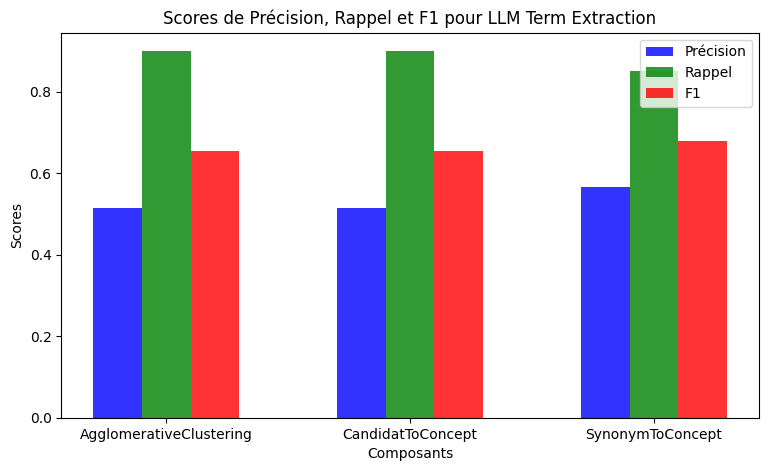

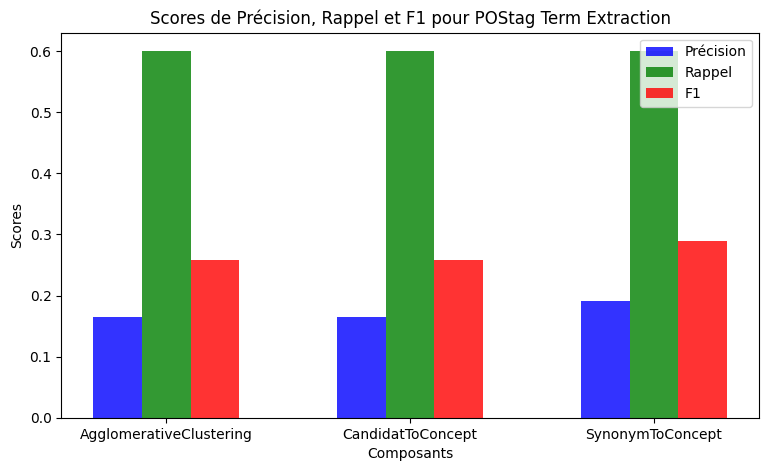

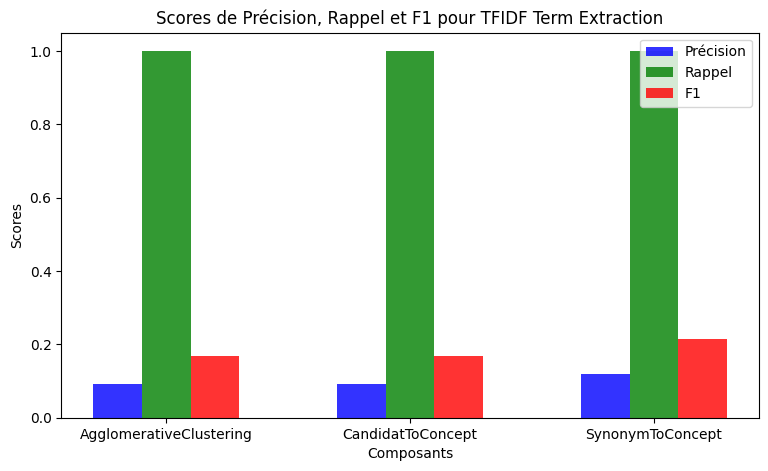

In [ ]:
# Fonction pour créer les diagrammes en barres
def create_bar_chart(index_name, data):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.2
    opacity = 0.8

    # Configurer les positions des barres
    r1 = np.arange(len(data.columns.levels[0]))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]

    precision = data.loc[index_name].xs('Precision', level=1)
    rappel = data.loc[index_name].xs('Rappel', level=1)
    f1 = data.loc[index_name].xs('F1', level=1)

    rects1 = ax.bar(r1, precision, bar_width, alpha=opacity, color='b', label='Précision')
    rects2 = ax.bar(r2, rappel, bar_width, alpha=opacity, color='g', label='Rappel')
    rects3 = ax.bar(r3, f1, bar_width, alpha=opacity, color='r', label='F1')

    ax.set_xlabel('Composants')
    ax.set_ylabel('Scores')
    ax.set_title(f'Scores de Précision, Rappel et F1 pour {index_name}')
    ax.set_xticks([r + bar_width for r in range(len(data.columns.levels[0]))])
    ax.set_xticklabels(data.columns.levels[0])
    ax.legend()

    plt.show()

# Créer un diagramme en barres pour chaque index
for idx in term_extraction_components:
    create_bar_chart(idx, pipelines_scores)

In [ ]:
def create_bar_chart(index_name, data):
    precision = data.loc[index_name].xs('Precision', level=1)
    rappel = data.loc[index_name].xs('Rappel', level=1)
    f1 = data.loc[index_name].xs('F1', level=1)

    fig = go.Figure(data=[
        go.Bar(name='Précision', x=data.columns.levels[0], y=precision),
        go.Bar(name='Rappel', x=data.columns.levels[0], y=rappel),
        go.Bar(name='F1', x=data.columns.levels[0], y=f1)
    ])
    
    # Modifier la disposition du graphique
    fig.update_layout(
        title=f'Scores de Précision, Rappel et F1 pour {index_name}',
        xaxis_title='Composants',
        yaxis_title='Scores',
        barmode='group'
    )
    
    fig.show()

data_long = pipelines_scores.reset_index().melt(id_vars='index', var_name=['Composant', 'Métrique'], value_name='Score')
data_long.rename(columns={'index': 'Extraction'}, inplace=True)

def create_bar_chart(index_name, data):
    df = data[data['Extraction'] == index_name]
    fig = px.bar(df, x='Composant', y='Score', color='Métrique', barmode='group',
                 title=f'Scores de Précision, Rappel et F1 pour {index_name}')
    
    fig.update_layout(
        xaxis_title='Composants',
        yaxis_title='Scores'
    )
    fig.update_layout(width=1000, height=600)
    fig.show()

# Créer un diagramme en barres pour chaque index
for idx in term_extraction_components:
    create_bar_chart(idx, data_long)

# Conclusion

In [ ]:
new_data = pd.DataFrame(index=term_extraction_components, columns=['Précision', 'Rappel', 'F1', 'Composant'])

# Trouver le composant avec la F1 la plus élevée pour chaque index
for idx in term_extraction_components:
    f1_values = pipelines_scores.loc[idx].xs('F1', level=1)
    max_f1_component = f1_values.idxmax()
    new_data.loc[idx, 'Précision'] = pipelines_scores.loc[idx, (max_f1_component, 'Precision')]
    new_data.loc[idx, 'Rappel'] = pipelines_scores.loc[idx, (max_f1_component, 'Rappel')]
    new_data.loc[idx, 'F1'] = pipelines_scores.loc[idx, (max_f1_component, 'F1')]
    new_data.loc[idx, 'Composant'] = max_f1_component

new_data.index = new_data.index + " / " + new_data['Composant']

# Supprimer la colonne 'Composant'
new_data.drop(columns=['Composant'], inplace=True)


# Afficher le nouveau DataFrame
print("\nNouveau DataFrame avec le composant ayant la plus grande F1:")
print(new_data)


Nouveau DataFrame avec le composant ayant la plus grande F1:
                                                 Précision Rappel        F1
LLM Term Extraction / AgglomerativeClustering     0.566667   0.85      0.68
POStag Term Extraction / AgglomerativeClustering  0.190476    0.6  0.289157
TFIDF Term Extraction / AgglomerativeClustering    0.11976    1.0  0.213904


In [ ]:
data_long = new_data.reset_index().melt(id_vars='index', var_name='Métrique', value_name='Score')
data_long.rename(columns={'index': 'Extraction - Composant'}, inplace=True)

# Créer le diagramme en barres groupées avec plotly.express
fig = px.bar(data_long, x='Extraction - Composant', y='Score', color='Métrique', barmode='group',
             title='Scores de Précision, Rappel et F1 pour chaque Extraction - Composant')

fig.update_layout(
    xaxis_title='Extraction - Composant',
    yaxis_title='Score'
)

fig.show()
